In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [32]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [33]:
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable


In [36]:
import sys
print(sys.executable)

C:\Users\seeyo\miniconda3\python.exe


In [38]:
!C:\Users\seeyo\miniconda3\python.exe -m pip install scipy

In [43]:
df = pd.read_csv('noisy_curvefit_data.csv')

In [44]:
print(df.shape) # shape of data set
print(df.head()) # first 5 rows
print(df.tail()) # last 5 rows
print(df.columns) # column names

(100, 6)
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850
Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')


## 2.1 inspecting the data frame
The data set has 100 rows and 6 columns.
The column names are "x", "y_noise_1", "y_noise_2", "y_noise_3", "y_noise_4", and "y_noise_5"

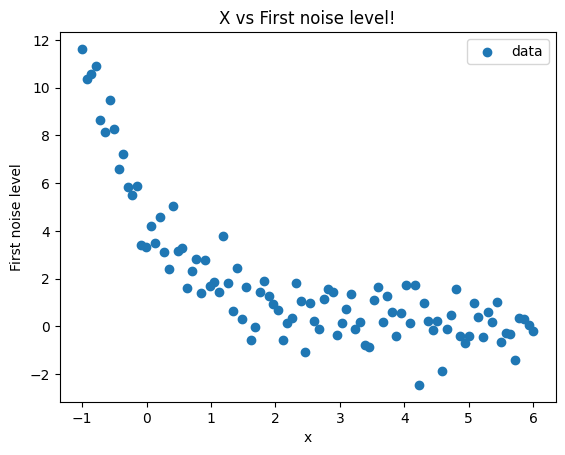

In [59]:
x = df['x']
y_noise_1 = df['y_noise_1']
plt.scatter(x, y_noise_1, label='data')
plt.xlabel("x")
plt.ylabel("First noise level")
plt.title("X vs First noise level!")
plt.legend()
plt.show()

## 2.2 fit the data

In [60]:
def model(x, A, k):
    return A * np.exp(-k * x)

p0 = [1, 1]
popt, pcobv = curve_fit(model, x, y_noise_1, p0=p0)

In [61]:
A_fit, k_fit = popt
f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)"

'Fit: y = 4.71 * e^(-0.92 * x)'

In [62]:
residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

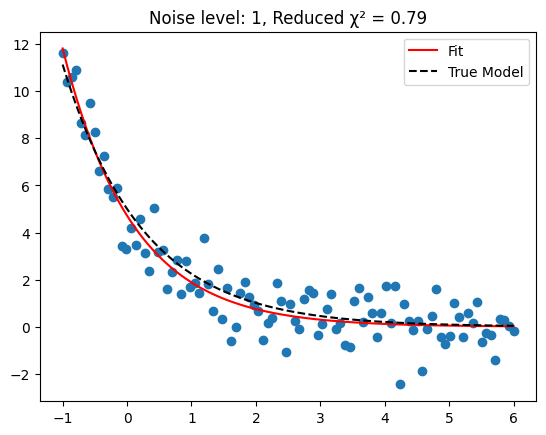

In [63]:
plt.scatter(x, y_noise_1)
plt.plot(x, model(x, A_fit, k_fit), 'r-', label="Fit")
plt.plot(x, model(x, 5, 0.8), 'k--', label="True Model")
plt.title(f"Noise level: 1, Reduced χ² = {chi2_reduced:.2f}")
plt.legend()
plt.show()

## 2.3 compare different noise levels

In [64]:
def fit_model(x, y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    residuals = y_noise_1 - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    return A_fit, k_fit, chi2_reduced

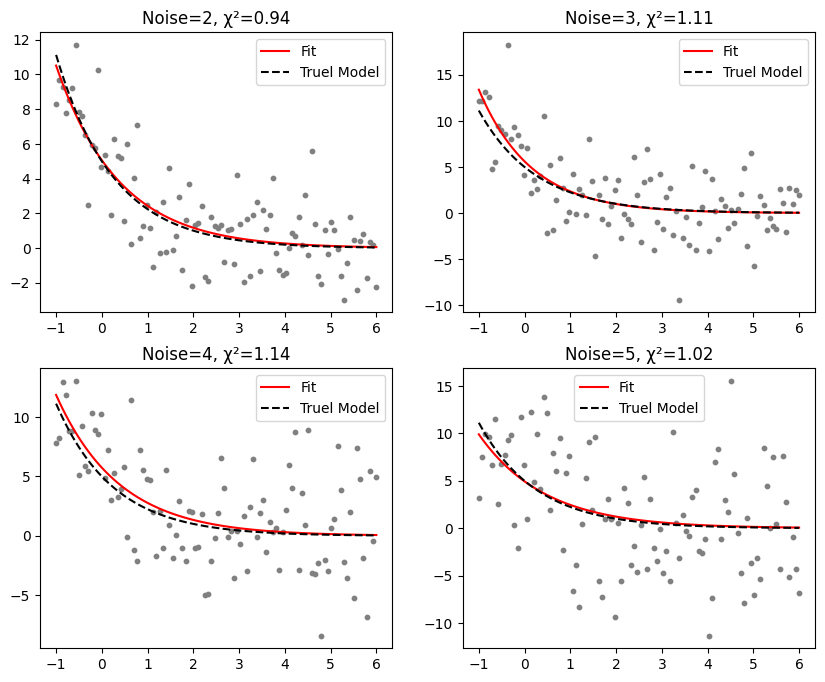

In [76]:
noise_level = [2, 3, 4, 5]
datasets = [df['y_noise_2'].values,
            df['y_noise_3'].values,
            df['y_noise_4'].values,
            df['y_noise_5'].values]

fig, axes = plt.subplots(2, 2, figsize =(10, 8))

for ax, y, level in zip(axes.flat, datasets, noise_level):
    A_fit, k_fit, chi2_red = fit_model(x, y)
    ax.scatter(x, y, color="gray", s=10)
    ax.plot(x, model(x, A_fit, k_fit), 'r-', label='Fit')
    ax.plot(x, model(x, 5, 0.8), 'k--', label='Truel Model')
    ax.set_title(f"Noise={level}, χ²={chi2_red:.2f}")
    ax.legend()
plt.show()

## 2.4 saving results

In [79]:
A_list = []
k_list = []
chi2_list = []

for level, y in zip(noise_levels, datasets):
    A_fit, k_fit, chi2_red = fit_model(x, y)
    
    A_list.append(A_fit)
    k_list.append(k_fit)
    chi2_list.append(chi2_red)

results = pd.DataFrame({
    'Noise Level': noise_levels,
    'A Fit': A_list,
    'k Fit': k_list,
    'Reduced Chi2': chi2_list
})

results = pd.DataFrame({
    'Noise Level': noise_levels,
    'A Fit': A_list,
    'k Fit': k_list,
    'Reduced Chi2': chi2_list
})

results

,Noise Level,A Fit,k Fit,Reduced Chi2
0,2,5.063889,0.730396,0.935444
1,3,5.609396,0.870372,1.110275
2,4,5.738727,0.725965,1.135896
3,5,4.943458,0.695012,1.017713


In [81]:
df.to_csv("noisy_parameters.csv", index=False)

## kepler's 3rd law